In [8]:
load_ext jupyter_black

The jupyter_black extension is already loaded. To reload it, use:
  %reload_ext jupyter_black


In [76]:
import matplotlib.pyplot as plt
import pickle
import pandas as pd
import seaborn as sns

In [10]:
demographics = {
    "cad": [
        "annotator_age",
        "annotator_education_level",
        "annotator_gender",
        "annotator_political",
    ],
    "cad_en": [
        "annotator_age",
        "annotator_education_level",
        "annotator_gender",
        "annotator_political",
        "annotator_ethnicity",
    ],
    "cad_hi": [
        "annotator_age",
        "annotator_education_level",
        "annotator_gender",
        "annotator_political",
        "annotator_ethnicity",
    ],
    "cad_pt": [
        "annotator_age",
        "annotator_education_level",
        "annotator_gender",
        "annotator_political",
        "annotator_ethnicity",
    ],
    "cad_fr": [
        "annotator_age",
        "annotator_education_level",
        "annotator_gender",
        "annotator_political",
        "annotator_ethnicity",
    ],
    "cad_it": [
        "annotator_age",
        "annotator_education_level",
        "annotator_gender",
        "annotator_political",
        "annotator_ethnicity",
    ],
    "chen": ["label"],
    "prism": [
        "age",
        "birth_region",
        "education",
        "employment_status",
        "english_proficiency",
        "ethnicity",
        "gender",
        "lm_familiarity",
        "marital_status",
        "religion",
        "reside_region",
    ],
}

In [13]:
data = {
    "dataset": [],
    "demographic": [],
    "balanced": [],
    "layer": [],
    "cv": [],
    "f1": [],
    "majority f1": [],
    "random f1": [],
    "majority aso": [],
    "random aso": [],
    "majority aso_better": [],
    "random aso_better": [],
}
for dataset in demographics:
    for demographic in demographics[dataset]:
        for balanced in [True, False]:
            with open(
                f"llama_probing_results/Llama-3.1-8B-Instruct_{dataset}_{demographic}{'_balanced' if balanced else ''}_scores.pkl",
                "rb",
            ) as infile:
                results = pickle.load(infile)
            for layer in results:
                for cv in range(5):
                    data["dataset"].append(dataset)
                    data["demographic"].append(demographic)
                    data["balanced"].append(balanced)
                    data["layer"].append(layer)
                    data["cv"].append(cv)
                    for score in ["f1", "majority f1", "random f1"]:
                        data[score].append(results[layer][score][cv])
                    for aso in ["majority aso", "random aso"]:
                        data[aso].append(results[layer][aso])
                        data[aso + "_better"].append(results[layer][aso] < 0.5)

df = pd.DataFrame(data)

In [14]:
df

,dataset,demographic,balanced,layer,cv,f1,majority f1,random f1,majority aso,random aso,majority aso_better,random aso_better
0,cad,annotator_age,True,0,0,0.332781,0.333885,0.488407,0.998918,0.995678,False,False
1,cad,annotator_age,True,0,1,0.331119,0.335533,0.492344,0.998918,0.995678,False,False
2,cad,annotator_age,True,0,2,0.329449,0.337173,0.495232,0.998918,0.995678,False,False
3,cad,annotator_age,True,0,3,0.333241,0.333425,0.512609,0.998918,0.995678,False,False
4,cad,annotator_age,True,0,4,0.330193,0.336445,0.491716,0.998918,0.995678,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
13115,prism,reside_region,False,31,0,0.334396,0.116732,0.162901,0.000000,0.000000,True,True
13116,prism,reside_region,False,31,1,0.318199,0.114204,0.167063,0.000000,0.000000,True,True
13117,prism,reside_region,False,31,2,0.312930,0.113488,0.164994,0.000000,0.000000,True,True
13118,prism,reside_region,False,31,3,0.343659,0.114510,0.171181,0.000000,0.000000,True,True


In [72]:
def line_plot(df, ax, legend):
    sns.lineplot(
        df,
        x="layer",
        y="f1",
        ax=ax,
        legend=legend,
        label="Probe",
    )
    sns.lineplot(
        df,
        x="layer",
        y="majority f1",
        ax=ax,
        legend=legend,
        label="Majority",
    )
    sns.lineplot(
        df,
        x="layer",
        y="random f1",
        ax=ax,
        legend=legend,
        label="Random",
    )
    if legend:
        ax.legend(loc="center left", bbox_to_anchor=(1, 0.5))

    better_than_baseline = (
        df.groupby("layer")[["majority aso_better", "random aso_better"]]
        .min()
        .min(axis=1)
    )

    m = ["o" if x else "x" for x in better_than_baseline]
    c = ["blue" if x else "red" for x in better_than_baseline]

    for layer in df["layer"].unique():
        ax.scatter(
            layer,
            df.loc[(df["layer"] == layer)]["f1"].mean(),
            marker=m[layer],
            color=c[layer],
        )
    ax.set_ylabel("Macro F1")

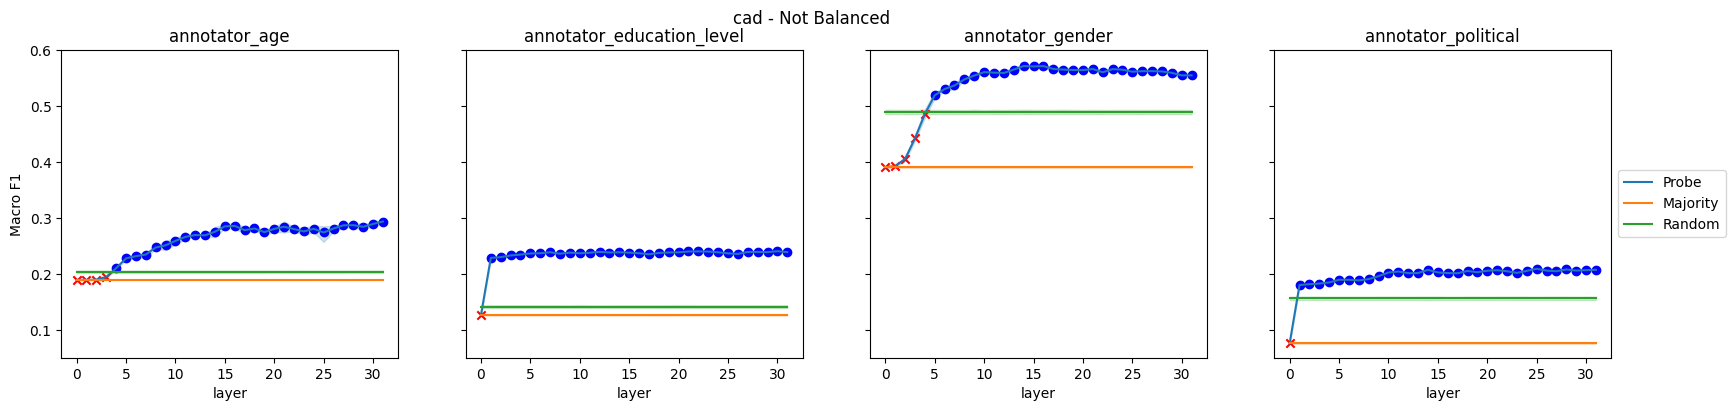

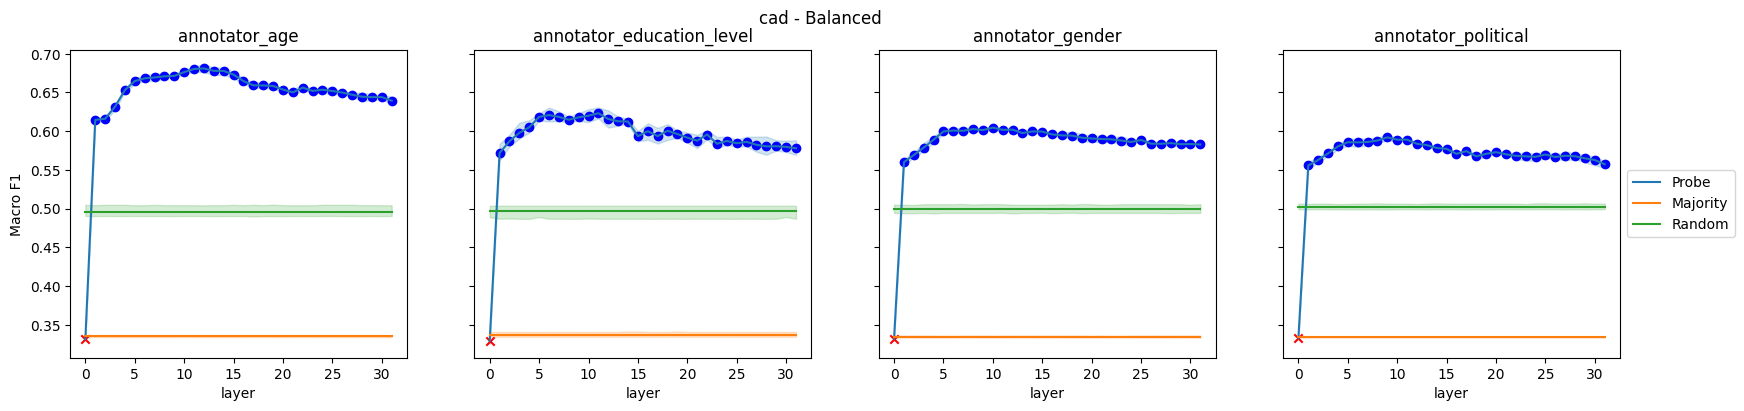

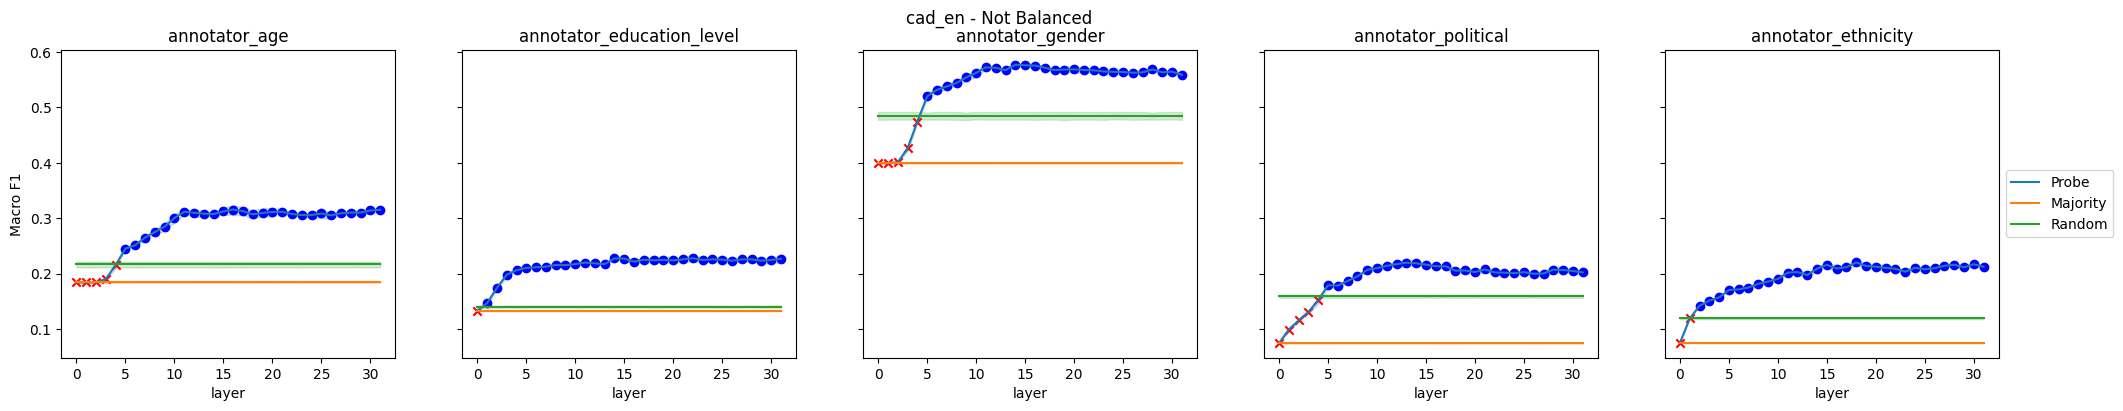

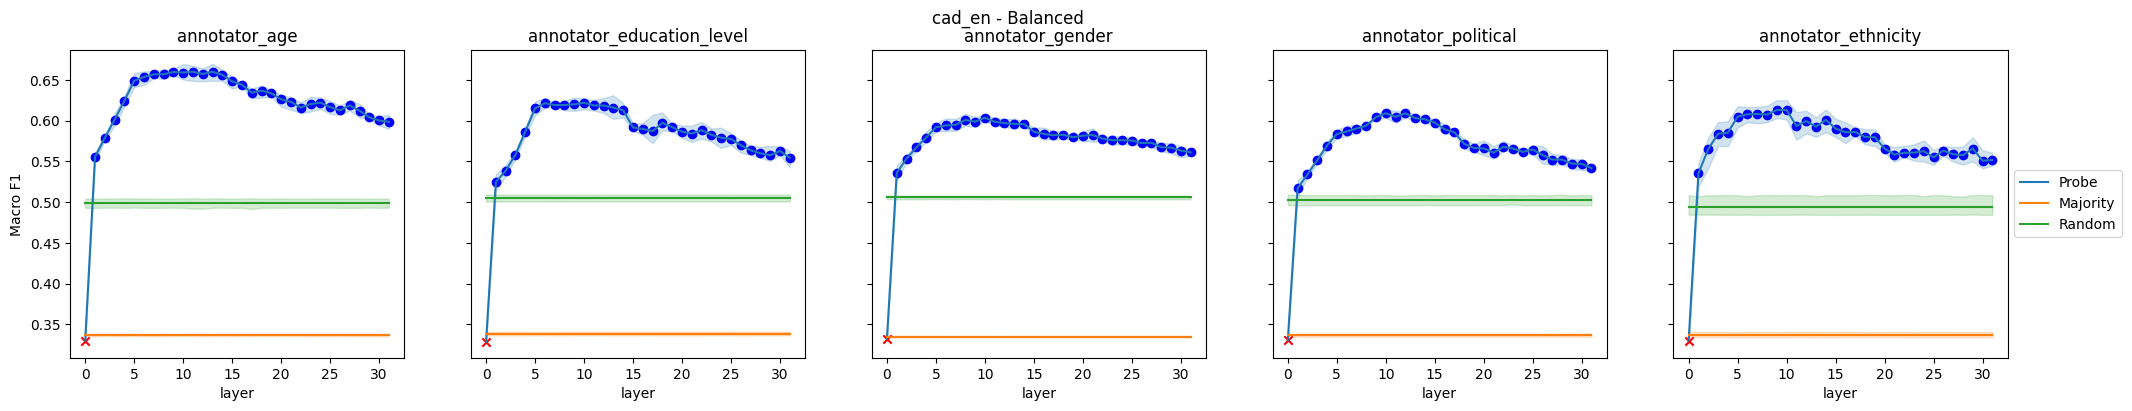

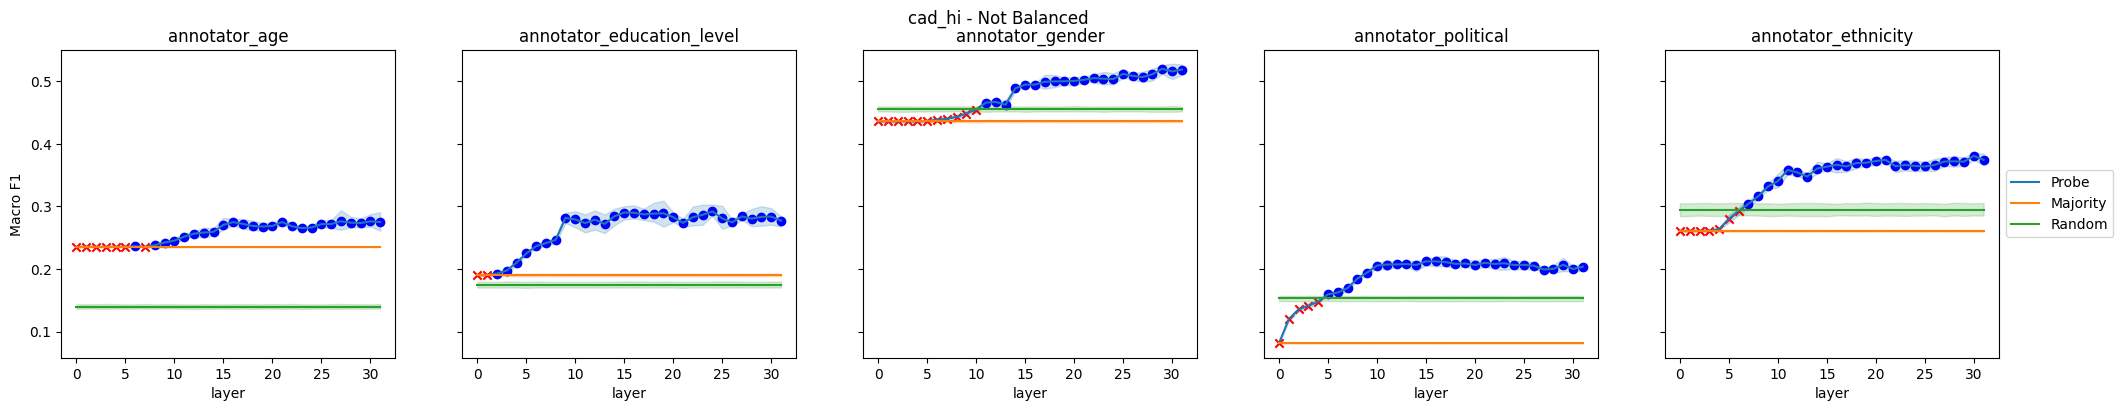

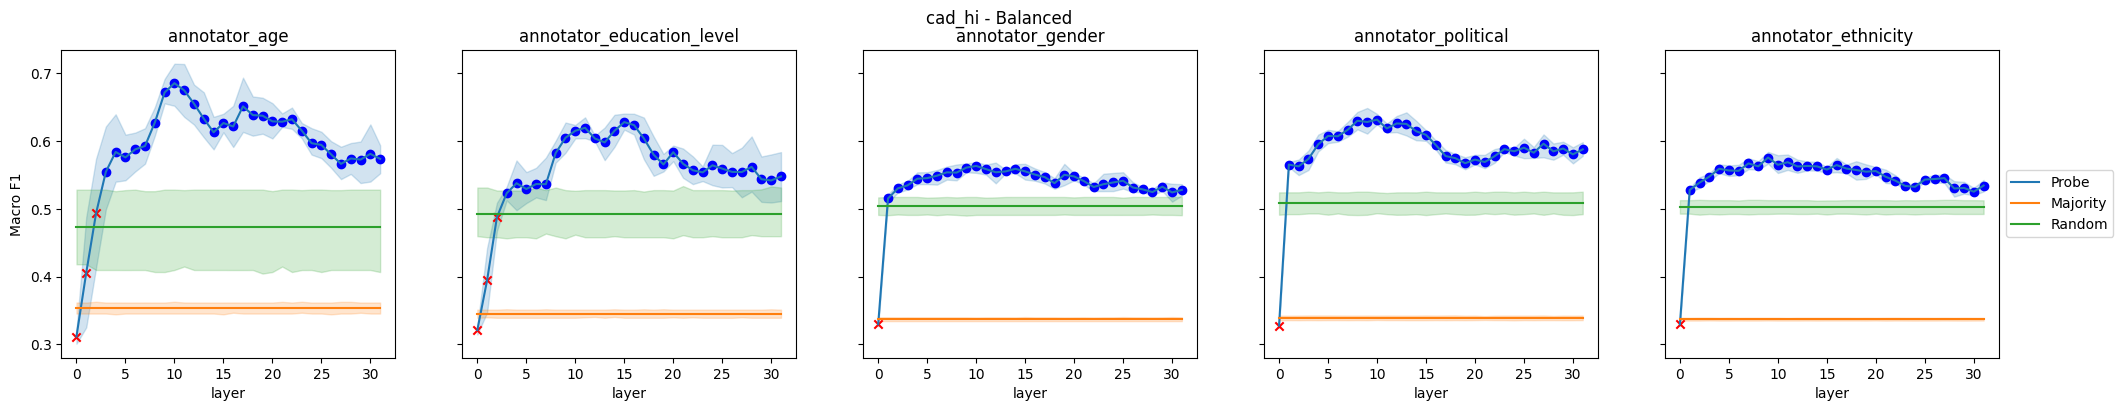

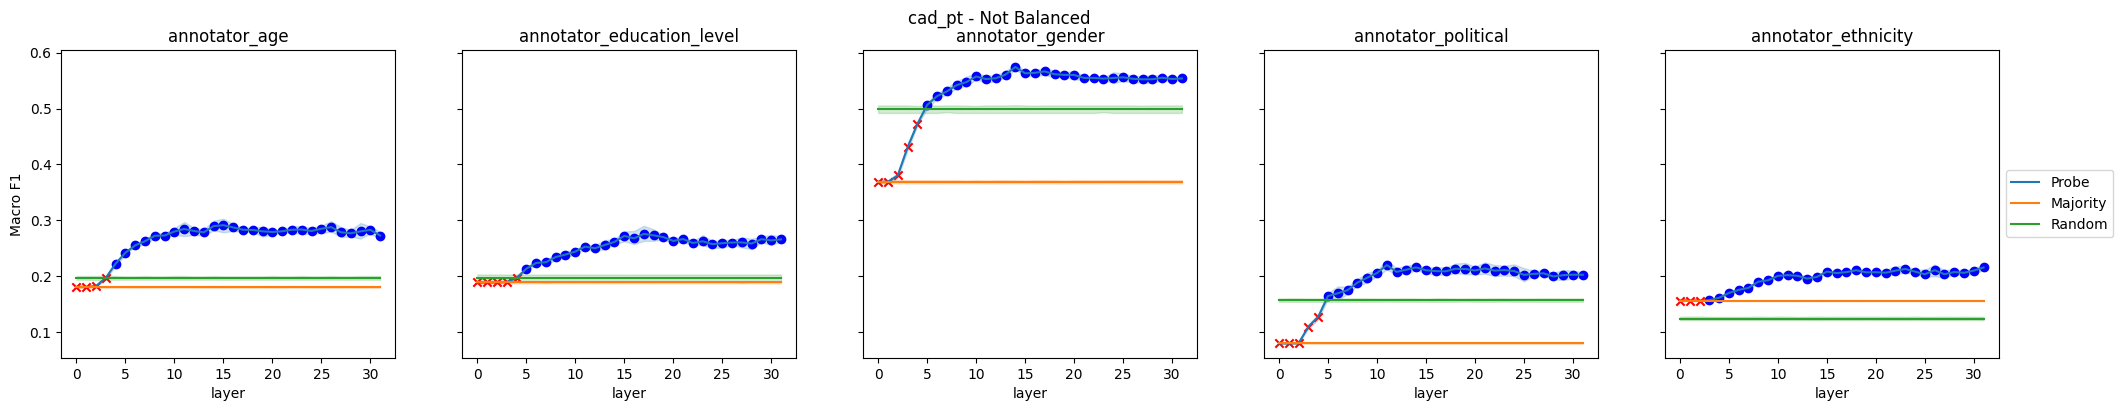

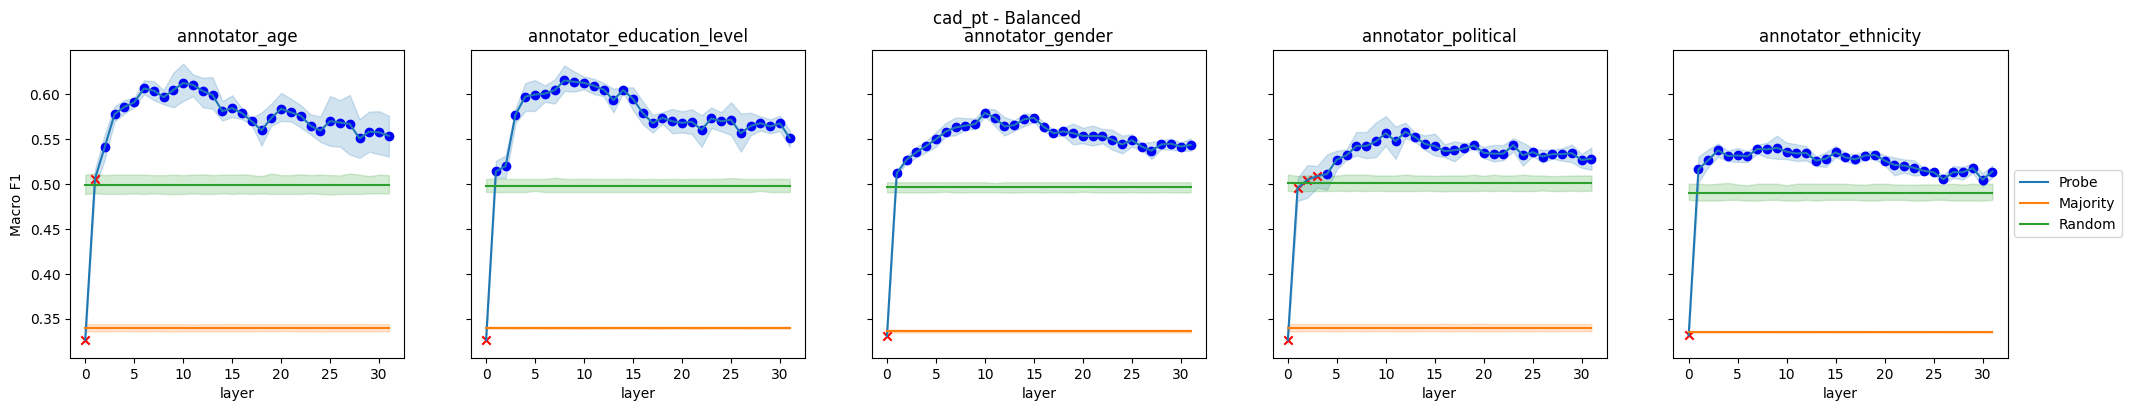

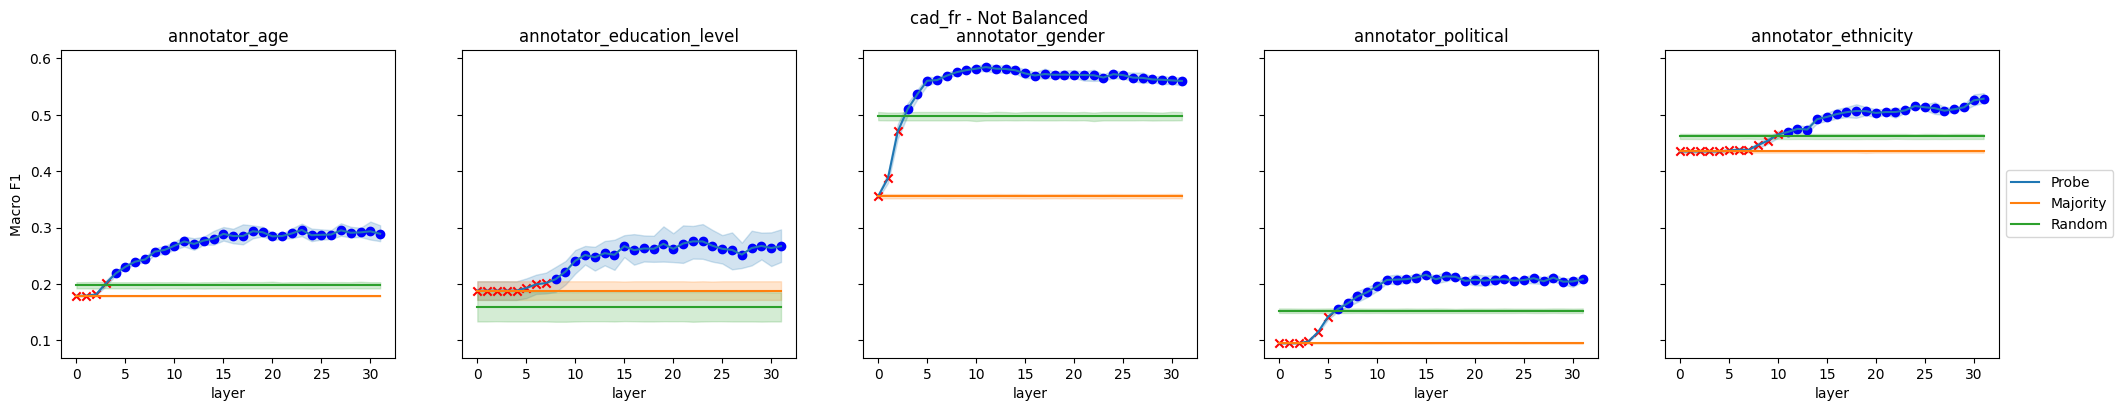

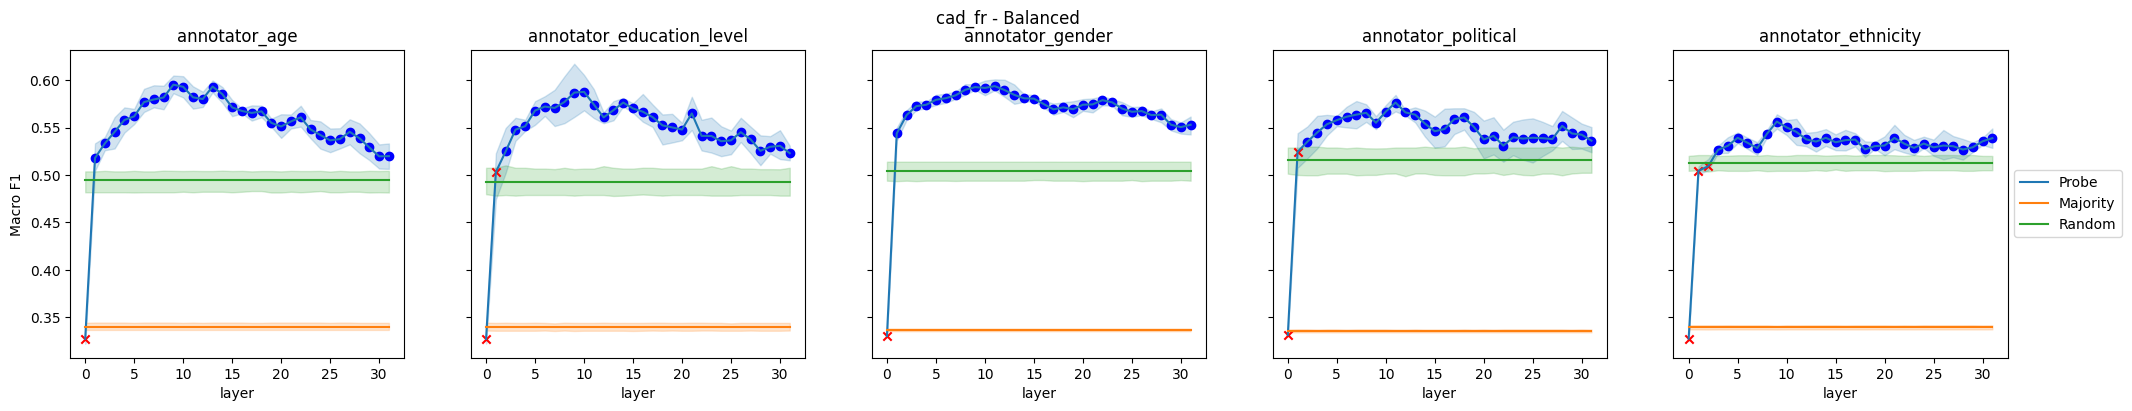

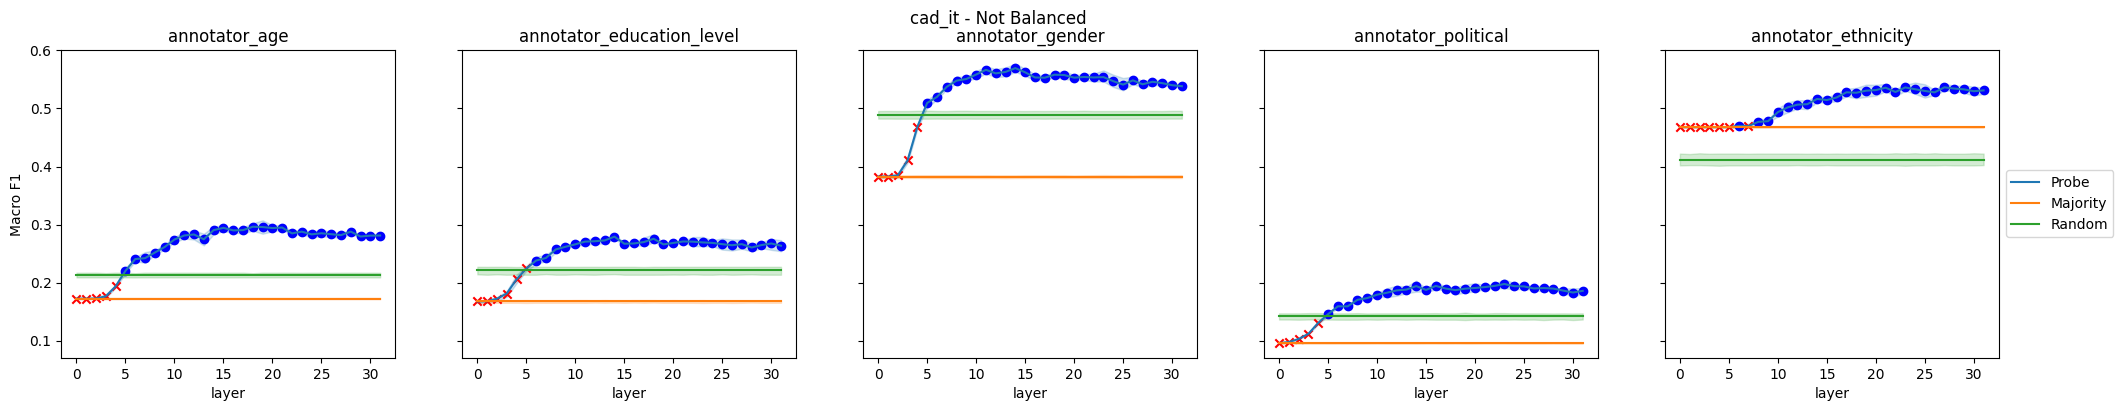

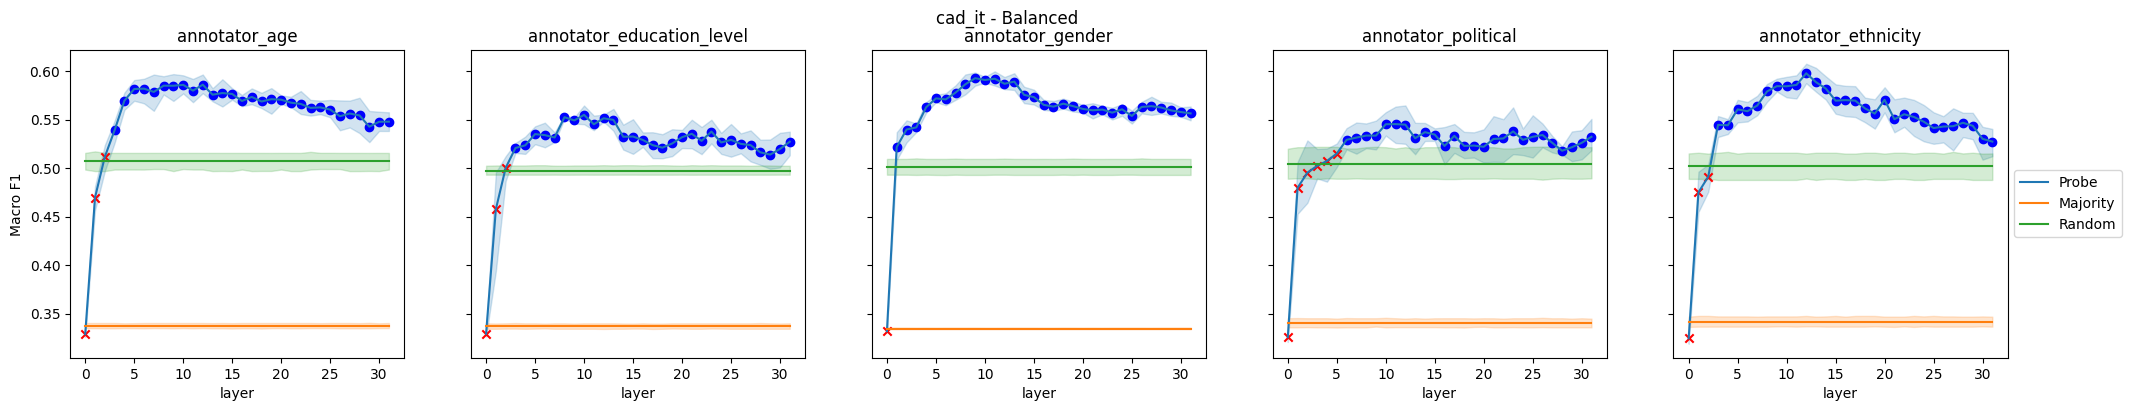

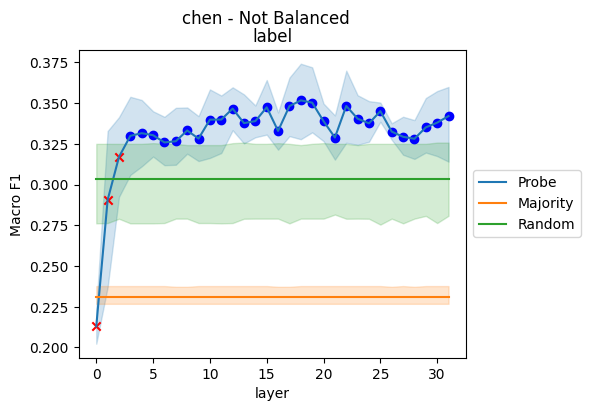

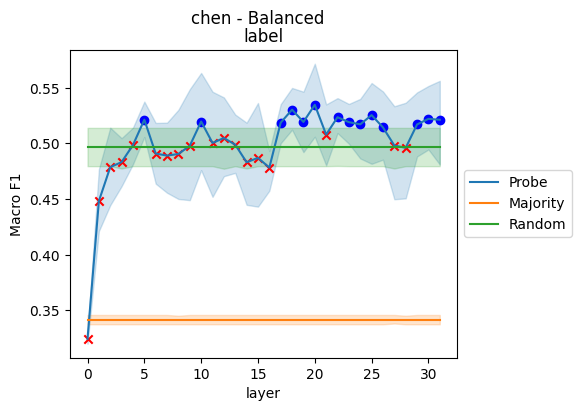

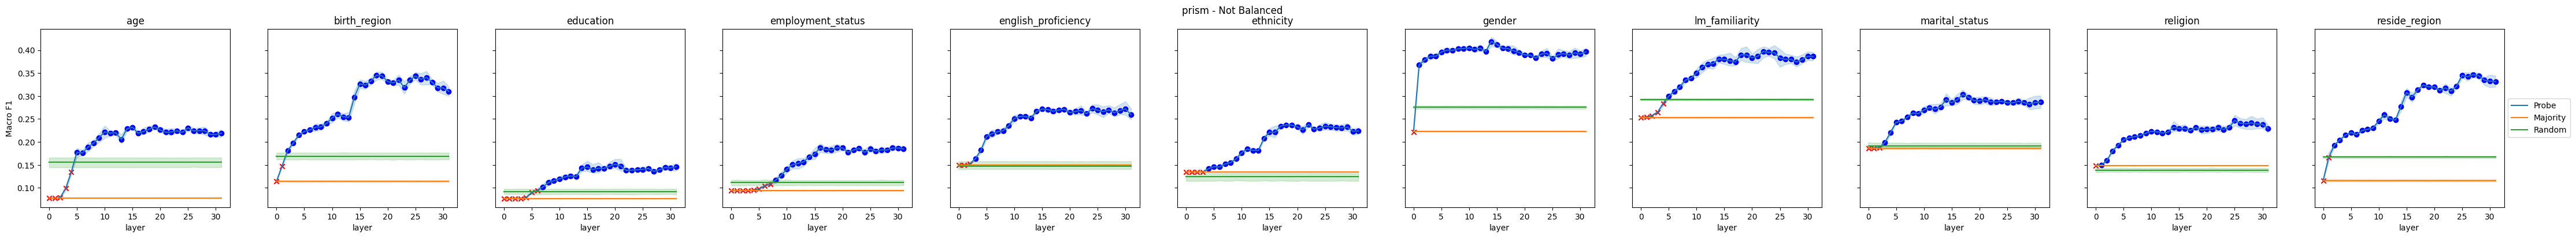

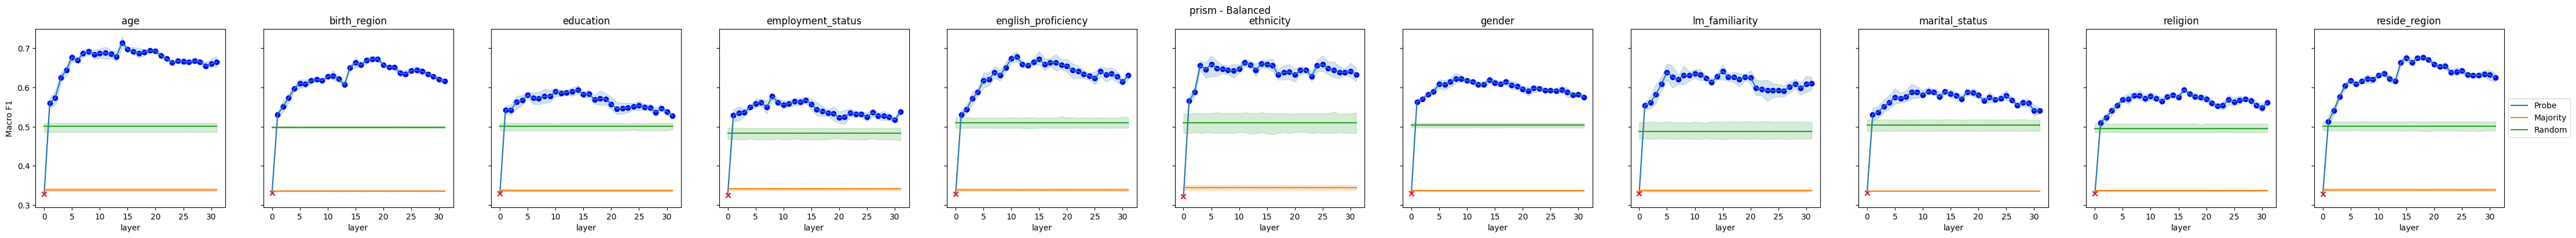

In [75]:
for dataset in demographics:
    fig, axes = plt.subplots(
        1,
        len(demographics[dataset]),
        figsize=(5 * len(demographics[dataset]), 4),
        sharey=True,
    )
    for d, demographic in enumerate(demographics[dataset]):
        if len(demographics[dataset]) > 1:
            ax = axes[d]
        else:
            ax = axes
        line_plot(
            df.loc[
                (df["dataset"] == dataset)
                & (df["demographic"] == demographic)
                & (df["balanced"] == False)
            ],
            ax,
            legend=d == len(demographics[dataset]) - 1,
        )
        ax.set_title(demographic)
    fig.suptitle(dataset + " - Not Balanced")
    plt.show()
    fig2, axes = plt.subplots(
        1,
        len(demographics[dataset]),
        figsize=(5 * len(demographics[dataset]), 4),
        sharey=True,
    )
    for d, demographic in enumerate(demographics[dataset]):
        if len(demographics[dataset]) > 1:
            ax = axes[d]
        else:
            ax = axes
        line_plot(
            df.loc[
                (df["dataset"] == dataset)
                & (df["demographic"] == demographic)
                & (df["balanced"] == True)
            ],
            ax,
            legend=d == len(demographics[dataset]) - 1,
        )
        ax.set_title(demographic)
    fig2.suptitle(dataset + " - Balanced")
    plt.show()